# 01 - Building the dataset

The forecasting problem is monthly oil demand for seven products across seven regions. The
OIES paper takes demand from IEA MODS and its predictors from Oxford Economics, both paid;
everything here is a free public substitute, so the first job is to show the substitutes
behave like the originals.

The second job is timing. Macro data describes a period that ended weeks or months before
anyone could read the number. A row dated January 2019 must contain only what had been
published by the end of January 2019, and most of this notebook is about getting that right
rather than approximately right.

Raw files sit in `data/<source>/`, the built tables in `data/oil.duckdb`, the SQL in `sql/`.

In [1]:
import sys
sys.path.insert(0, "../src")

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

import config as c
import data

pd.set_option("display.width", 130)
plt.rcParams.update({"figure.figsize": (11, 3.4), "axes.grid": True, "grid.alpha": .3})

data.query("SELECT table_name, estimated_size AS rows FROM duckdb_tables() ORDER BY 1")

,table_name,rows
0,demand,13077
1,panel,2031
2,predictors,28964


## The demand file

JODI-Oil publishes monthly demand by product for around 110 countries. The download is one
650 MB csv holding every flow, unit and product it collects, of which we want one flow
(`TOTDEMO`), one unit (`KBD`, thousand barrels per day, the paper's unit) and seven
products. Loading it into pandas to throw away 95% of it is the wrong move, so `sql/demand.sql`
queries it in place.

In [2]:
raw = f"read_csv_auto('{c.JODI_DIR / 'jodi_secondary.csv'}', all_varchar = true)"

duckdb.sql(f"""
    SELECT FLOW_BREAKDOWN AS flow, UNIT_MEASURE AS unit, COUNT(*) AS rows
    FROM {raw}
    GROUP BY 1, 2
    ORDER BY rows DESC
    LIMIT 5
""").df()

,flow,unit,rows
0,PTRANSF,KBD,311040
1,RECEIPTS,KL,311040
2,REFGROUT,KTONS,311040
3,STOCKCH,KBD,311040
4,TOTEXPSB,KBD,311040


### Control: which kerosene column is which

JODI reports both `KEROSENE` and `JETKERO`. If they were siblings you would add them; if one
contains the other, adding them double counts jet fuel. Test it against JODI's own total:
the seven products we map should reconstruct `TOTPRODS`.

In [3]:
duckdb.sql(f"""
    WITH wide AS (
        SELECT REF_AREA, TIME_PERIOD,
               MAX(CASE WHEN ENERGY_PRODUCT = 'TOTPRODS' THEN TRY_CAST(OBS_VALUE AS DOUBLE) END) AS total,
               SUM(CASE WHEN ENERGY_PRODUCT IN ('LPG','NAPHTHA','GASOLINE','KEROSENE',
                                                'GASDIES','RESFUEL','ONONSPEC')
                        THEN TRY_CAST(OBS_VALUE AS DOUBLE) END) AS seven,
               MAX(CASE WHEN ENERGY_PRODUCT = 'JETKERO' THEN TRY_CAST(OBS_VALUE AS DOUBLE) END) AS jet
        FROM {raw}
        WHERE FLOW_BREAKDOWN = 'TOTDEMO' AND UNIT_MEASURE = 'KBD'
        GROUP BY 1, 2
        HAVING total > 0 AND seven IS NOT NULL AND jet IS NOT NULL
    )
    SELECT COUNT(*) AS country_months,
           ROUND(MEDIAN(ABS(seven - total) / total) * 100, 3) AS pct_gap_seven,
           ROUND(MEDIAN(ABS(seven + jet - total) / total) * 100, 3) AS pct_gap_with_jet
    FROM wide
""").df()

,country_months,pct_gap_seven,pct_gap_with_jet
0,14413,0.041,5.115


0.04% against 5%: `JETKERO` is the jet subset of `KEROSENE`, and adding it would inflate d4
by the whole of jet fuel. `config.JODI_PRODUCTS` maps `KEROSENE` alone.

### From countries to the paper's regions

`sql/demand.sql` does the country-to-region join, the product map and the sum in one query.
It also returns how many countries reported, because a regional total is the sum of whoever
showed up that month.

In [4]:
demand = data.query("SELECT * FROM demand ORDER BY region, product, month")
print(f"{len(demand):,} region-product-months, {demand.month.min():%Y-%m} to {demand.month.max():%Y-%m}")
demand.head()

13,077 region-product-months, 2002-01 to 2026-06


,region,product,month,kbd,reporters
0,apac,d1_lpg,2002-01-01,1000.3690,4
1,apac,d1_lpg,2002-02-01,970.5138,4
2,apac,d1_lpg,2002-03-01,903.2403,4
3,apac,d1_lpg,2002-04-01,927.4499,4
4,apac,d1_lpg,2002-05-01,845.6173,4


### Control: against the paper's Table 3

The paper prints US 2019 demand by product. Where the product definitions agree, JODI should
land on top of it.

In [5]:
ours = data.query("""
    SELECT product, ROUND(AVG(kbd)) AS kbd
    FROM demand
    WHERE region = 'us' AND YEAR(month) = 2019
    GROUP BY 1
    ORDER BY 1
""").set_index("product").kbd

paper = pd.Series({"d1_lpg": 2638, "d2_naphtha": 207, "d3_gasoline": 9296, "d4_jetkero": 1760,
                   "d5_gasoil": 4112, "d6_fueloil": 306, "d7_other": 2260})
check = pd.DataFrame({"paper (IEA MODS)": paper, "ours (JODI)": ours})
check["diff %"] = (100 * (check["ours (JODI)"] / check["paper (IEA MODS)"] - 1)).round(1)
check

,paper (IEA MODS),ours (JODI),diff %
d1_lpg,2638,1109.0,-58.0
d2_naphtha,207,207.0,0.0
d3_gasoline,9296,9344.0,0.5
d4_jetkero,1760,1764.0,0.2
d5_gasoil,4112,4133.0,0.5
d6_fueloil,306,308.0,0.7
d7_other,2260,3536.0,56.5


Five of seven within 1%. The two that miss are a definition difference rather than an error:
JODI's LPG excludes ethane and the paper's includes it, so roughly 1.5 mb/d sits in our
`d7_other` instead of `d1_lpg`. The pair adds to 4,645 kb/d against the paper's 4,898. The
model is trained and scored on one definition throughout, so this shifts which product
carries the ethane, not the total.

### Control: is the coverage stable?

`v_regional_demand` puts annual demand next to the reporter count. Reading them together is
the check that matters: JODI collects from countries that volunteer, and volunteers leave.

In [6]:
coverage = data.query("SELECT * FROM v_regional_demand WHERE year IN (2010, 2015, 2019, 2023, 2025)")
print("demand, mb/d")
print(coverage.pivot(index="year", columns="region", values="mb_per_day").round(1).to_string())
print()
print("countries reporting")
print(coverage.pivot(index="year", columns="region", values="reporters").astype(int).to_string())

demand, mb/d
region  apac  china  europe  india  other_americas  other_non_oecd    us
year                                                                    
2010     8.0    9.0    13.6    3.1             4.6            20.2  19.4
2015     8.0   10.9    12.8    3.9             4.6            22.1  19.7
2019     7.9   13.7    13.2    4.8             4.7            19.2  20.4
2023     7.5   16.1    12.4    5.1             4.3            13.7  20.4
2025     7.4   16.6    12.4    5.5             4.4            12.1  20.7

countries reporting
region  apac  china  europe  india  other_americas  other_non_oecd  us
year                                                                  
2010       4      1      19      1               3              59   1
2015       4      1      19      1               3              63   1
2019       4      1      19      1               3              45   1
2023       4      1      19      1               3              39   1
2025       4      1      19  

The six named regions are stable - the US holds 20 mb/d, China grows, Europe drifts down as
it should. Other non-OECD collapses from 22 mb/d to 12 while its reporter count falls, which
is members leaving JODI rather than a continent halving its oil use.

Two consequences carried forward:

- the six named regions are fit for a level forecast; **other non-OECD is not**, and its
  numbers are a data artefact rather than a demand view;
- the 2019 test window sits before most of the erosion, so the US and China comparisons with
  the paper are unaffected.

One more read on the same table, as a shape check: the product mix should look like the
economies it comes from.

In [7]:
mix = data.query("""
    SELECT region, product, ROUND(pct, 1) AS pct
    FROM v_product_mix
    WHERE year = 2019
""")
mix.pivot(index="region", columns="product", values="pct")

product,d1_lpg,d2_naphtha,d3_gasoline,d4_jetkero,d5_gasoil,d6_fueloil,d7_other
region,,,,,,,
apac,9.4,24.9,18.3,11.3,23.5,5.3,7.4
china,13.8,6.5,21.3,6.0,21.2,3.8,27.3
europe,7.5,6.8,14.2,10.6,44.6,5.3,10.9
india,17.5,6.9,14.5,5.0,36.0,2.3,17.8
other_americas,12.0,1.0,33.6,6.1,24.0,4.4,18.8
other_non_oecd,12.4,3.5,26.4,6.6,32.6,10.3,8.3
us,5.4,1.0,45.8,8.6,20.3,1.5,17.3


Gasoline is 46% of US barrels and 14% of Europe's, where gasoil is 45%; China puts 27% into
other products, which is the ethane and petrochemical feedstock line. That is the right shape, and a mapping error would not produce it.

## Timestamps: reference period is not availability

Every predictor observation carries two dates - the last day of the period it describes, and
the day it was published. `config.LAG` holds the gap for each source, and they are
publication conventions rather than guesses.

In [8]:
print(c.LAG)
data.query("SELECT * FROM v_publication_lag").head(12)

{'demand': 2, 'price': 0, 'fred_monthly': 1, 'fred_quarterly': 1, 'aviation': 2, 'oecd': 2, 'worldbank': 12, 'trade': 2}


,variable,source,observations,lag_months
0,airp,worldbank,238,12.0
1,egen,worldbank,208,12.0
2,gdp,worldbank,72,12.0
3,inv,worldbank,70,12.0
4,pop,worldbank,216,12.0
5,airf,fred,3150,2.0
6,cbui,oecd,1248,2.0
7,cons,oecd,529,2.0
8,cpi,oecd,1560,2.0
9,gdp,oecd,423,2.0


### Aligning with `merge_asof`

The panel is monthly. Predictors arrive on their own calendars - monthly, quarterly, annual -
each on its own publication schedule. That is exactly the asynchronous case
`merge_asof(direction="backward")` is for: as of the end of month t, take the most recent
observation whose `available_at` is on or before t.

A `tolerance` of two years goes with it. A series that has not printed in two years has not
merely slipped, it has stopped, and carrying its last value forward forever would be a silent
fiction. Past the tolerance the value goes missing, which XGBoost handles.

In [9]:
releases = data.query("""
    SELECT period_end, available_at, ROUND(value, 1) AS value
    FROM predictors
    WHERE region = 'us' AND variable = 'gdp'
      AND available_at BETWEEN DATE '2018-09-01' AND DATE '2019-05-31'
    ORDER BY available_at
""")
print("US GDP releases either side of the 2019 forecast origin:")
print(releases.to_string(index=False))

panel = data.load_panel()
us = panel[panel.region == "us"].set_index("month")
print()
print("what the panel carries:")
print(us.loc["2018-10":"2019-04", ["gdp", "cpi", "ind", "rpo"]].to_string())

US GDP releases either side of the 2019 forecast origin:
period_end available_at   value
2018-09-30   2018-10-30 20798.7
2018-12-31   2019-01-31 20917.9
2019-03-31   2019-04-30 21111.6

what the panel carries:
                  gdp      cpi       ind        rpo
month                                              
2018-10-01  20798.730  252.182  104.1004  80.783478
2018-11-01  20798.730  252.772  103.9856  66.228636
2018-12-01  20798.730  252.594  104.0681  57.948095
2019-01-01  20917.867  252.767  104.0936  59.944783
2019-02-01  20917.867  252.561  103.4021  64.384000
2019-03-01  20917.867  253.319  102.8371  66.941905
2019-04-01  21111.600  254.277  102.8757  71.475909


December 2018 carries Q3 GDP, because Q4 did not exist yet. January 2019 steps to Q4. That is
the whole point.

### What interpolating would have done

The paper converts quarterly predictors to monthly with `interpolate(method="linear")`. It is
smooth and convenient, and it reads the *next* quarter's number to fill the months in between.
Through a turning point the difference is not cosmetic.

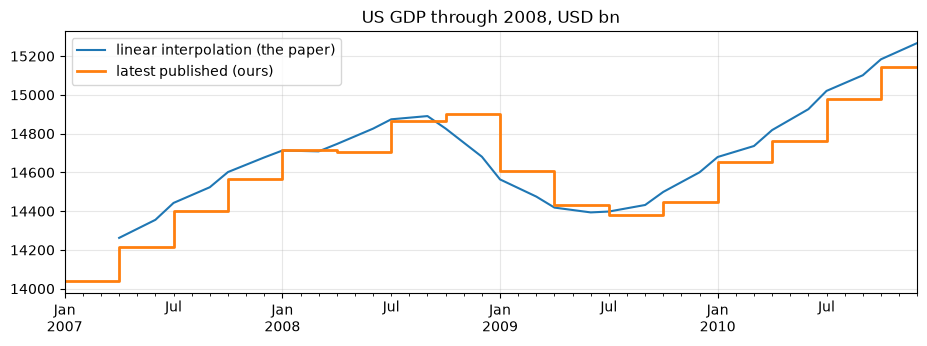

In [10]:
quarterly = data.query("""
    SELECT period_end, value FROM predictors
    WHERE region = 'us' AND variable = 'gdp'
      AND period_end BETWEEN DATE '2007-01-01' AND DATE '2010-12-31'
    ORDER BY period_end
""").set_index("period_end").value
interpolated = quarterly.resample("MS").interpolate("linear")

fig, ax = plt.subplots()
interpolated.plot(ax=ax, label="linear interpolation (the paper)")
us.gdp.loc["2007":"2010"].plot(ax=ax, drawstyle="steps-post", lw=2, label="latest published (ours)")
ax.set_title("US GDP through 2008, USD bn"); ax.set_xlabel(""); ax.legend();

The interpolated line starts falling months before the fall was reported. A model trained on
it learns to see recessions early and cannot repeat the trick out of sample.

## Missing values

Two kinds, treated differently.

In [11]:
(panel.set_index(["region", "month"]).isna().groupby("region").mean() * 100).round(0).astype(int).T

region,apac,china,europe,india,other_americas,other_non_oecd,us
d1_lpg,0,0,0,0,0,0,0
d2_naphtha,29,27,29,29,29,29,29
d3_gasoline,0,0,0,0,0,0,0
d4_jetkero,0,0,0,0,0,0,0
d5_gasoil,0,0,0,0,0,0,0
d6_fueloil,0,0,0,0,0,0,0
d7_other,29,22,29,29,29,29,29
airf,0,0,0,0,0,0,0
airp,0,0,0,0,0,0,0
cbui,0,0,0,100,0,100,0


- **Whole columns missing for a region.** China has no free monthly production index and no
  OECD quarterly accounts; `chem` and `ppi` are US-only. These stay missing. XGBoost splits on
  missing natively, which is one of the reasons the paper chose it, and inventing a number for
  China's industrial production would be worse than admitting we do not have one.
- **A leading gap.** JODI only reports naphtha and other products from 2009, so those two
  columns are empty for the first seven years. The paper backcasts them with Prophet. We do
  not: fabricating seven years of history from a trend fitted to the later data is a large
  liability for two products, and the model trains on the sample that exists.

## Sanity checks

In [12]:
for region, part in panel.groupby("region"):
    assert part.month.is_unique and part.month.is_monotonic_increasing, region
    assert len(part) == len(pd.date_range(part.month.min(), part.month.max(), freq="MS")), region

nonpositive = data.query("SELECT region, product, month, kbd FROM demand WHERE kbd <= 0")
world = panel.groupby("month")[c.PRODUCTS].sum().sum(axis=1) / 1000

print(f"regions               {panel.region.nunique()}, months contiguous and unique")
print(f"months per region     {sorted(panel.groupby('region').size().unique())}")
print(f"non-positive demand   {len(nonpositive)} rows")
print(nonpositive.to_string(index=False))
print()
print(f"world demand 2019     {world.loc['2019'].mean():.1f} mb/d   (IEA reported 100.1)")
print(f"world demand 2023     {world.loc['2023'].mean():.1f} mb/d   (IEA reported 101.7)")

regions               7, months contiguous and unique
months per region     [np.int64(270), np.int64(291), np.int64(294)]
non-positive demand   1 rows
region    product      month  kbd
    us d2_naphtha 2026-06-01  0.0

world demand 2019     83.9 mb/d   (IEA reported 100.1)
world demand 2023     79.4 mb/d   (IEA reported 101.7)


One zero, US naphtha in the most recent month, which is late reporting rather than a real
observation. It sits seven years past the test window so it never reaches the model, but a
zero is worth naming: MAPE divides by the actual, so a zero in a scored month would blow the
metric up rather than merely degrade it.

84 mb/d against the IEA's 100.1 is JODI's coverage, consistent with the reporter table above.

---

`panel` in `data/oil.duckdb` is the modelling table: one row per region-month, seven demand
columns and nineteen drivers, every driver as of information available that month. Notebook
02 turns it into a supervised learning problem.